In [ ]:
"""
Data Cleaning Pipeline — Mental Health Text Classification
==========================================================
Thứ tự xử lý:
  1. ftfy      : sửa mojibake / encoding lỗi
  2. emoji     : chuyển emoji → text mô tả (tiếng Anh) (mỗi mô hình lưu ý xử lý kỹ chỗ này cho embedding :tag:)
  3. Các bước  : URL -> <url>, @mention -> <username> , #hashtag -> hashtag, repeated chars, whitespace

Ghi chú thiết kế:
- Giữ nguyên CASE (BERT cần; lowercase tuỳ model sau)
- Giữ dấu câu cơ bản (!, ?, ...) vì EDA cho thấy chúng có tín hiệu phân lớp
- Không xoá stopword ở đây (để cho TF-IDF / tokenizer quyết định)
"""

'\nData Cleaning Pipeline — Mental Health Text Classification\n==========================================================\nThứ tự xử lý:\n  1. ftfy      : sửa mojibake / encoding lỗi\n  2. emoji     : chuyển emoji → text mô tả (tiếng Anh) (mỗi mô hình lưu ý xử lý kỹ chỗ này cho embedding :tag:)\n  3. Các bước  : URL -> <url>, @mention -> <username> , #hashtag -> hashtag, repeated chars, whitespace\n\nGhi chú thiết kế:\n- Giữ nguyên CASE (BERT cần; lowercase tuỳ model sau)\n- Giữ dấu câu cơ bản (!, ?, ...) vì EDA cho thấy chúng có tín hiệu phân lớp\n- Không xoá stopword ở đây (để cho TF-IDF / tokenizer quyết định)\n'

In [ ]:
!pip install ftfy emoji wordsegment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 67.6 MB/s eta 0:00:00


In [ ]:
import re
import ftfy
import emoji
import html
import pandas as pd
from typing import Optional
import unicodedata

from wordsegment import load, segment
load()

In [ ]:
# ── 1. Sửa mojibake & encoding lỗi ──────────────────────────────────────────

def fix_encoding(text: str) -> str:
    """
    Fix mojibake and encoding errors using ftfy.
    Examples: "cafÃ©" → "café", smart quotes corruption, etc.
    """
    return ftfy.fix_text(text)

In [ ]:
# ── 2. Chuyển emoji → text mô tả ────────────────────────────────────────────

def convert_emoji(text: str, language: str = "en") -> str:
    """
    Convert emoji to descriptive :tag: format using emoji.demojize().
    Example: "I'm so sad 😢" → "I'm so sad :crying_face:"
    """
    text = emoji.demojize(text, language=language)
    # Prevent tag merging: ":tag1::tag2:" → ":tag1: :tag2:"
    text = text.replace("::", ": :")
    text = re.sub(r":(\w+):", r"\1", text)
    return text

In [ ]:
# ── 3. Xoá URL ───────────────────────────────────────────────────────────────

def clean_urls(text: str) -> str:
    """
    Replace URLs with <url> placeholder.
    WHY <url> instead of removing: preserves the fact that a link was present,
    which can indicate external reference behavior (relevant for some analyses).

    Example: "check https://t.co/xxx now" → "check <url> now"
    """
    return re.sub(r"https?://\S+|www\.\S+", " <url> ", text)

In [ ]:
# ── 4. Xoá @mention và #hashtag ─────────────────────────────────────────────

def clean_mentions(text: str) -> str:
    """
    Replace @username with <username> placeholder.
    WHY <username> instead of [USER]: consistent with <url> convention,
    and more explainable (clearly a social media artifact).

    Example: "@MagicMagid hello" → "<username> hello"
    """
    return re.sub(r"@\w+", " <username> ", text)

In [ ]:
# ── 5. Clean hashtag ─────────────────────────────────────────────

# def clean_hashtags(text: str) -> str:
#     """
#     Rút gọn theo chiến lược v4: Loại bỏ hashtag rác, giữ nguyên thân hashtag ý nghĩa.
#     """
#     def process_match(match):
#         body = match.group(1)
#         body_low = body.lower()

#         # Hợp nhất 5 quy tắc phát hiện rác (Trash Detection) [cite: 268]
#         is_trash = (
#             body_low == 'x200b' or                    # 1. Reddit artifact [cite: 62]
#             body.isdigit() or                         # 2. Số thuần túy [cite: 71]
#             len(body) <= 2 or                         # 3. Quá ngắn [cite: 74]
#             not body.isascii() or                     # 5. Lỗi encoding [cite: 80]
#             (3 <= len(body) <= 6 and                  # 4. Bot/Spam (Alphanumeric ngẫu nhiên)
#              not body.isalpha() and not body.isdigit())
#         )

#         # Nếu là rác thì xóa (trả về chuỗi rỗng), nếu không thì bỏ dấu # (trả về body) [cite: 249, 250]
#         return "" if is_trash else body

#     # Sử dụng callback để xử lý tất cả hashtag trong 1 lần quét duy nhất
#     cleaned_text = re.sub(r'#(\w+)', process_match, text)

#     # Xử lý khoảng trắng thừa do việc xóa hashtag để lại
#     return " ".join(cleaned_text.split())

def clean_hashtags(text: str) -> str:
    return re.sub(r'#(\w+)', r'\1', text)

In [ ]:
# ── 6. Chuẩn hoá repeated characters ────────────────────────────────────────

def normalize_repeated_chars(text: str, max_repeat: int = 2) -> str:
    """
    Reduce repeated characters: "sooooo" → "soo", "ahhhhh" → "ahh".
    """
    text = re.sub(rf"([a-zA-Z])\1{{{max_repeat},}}", r"\1" * max_repeat, text)
    text = re.sub(rf"(\W)\1{{{max_repeat},}}", r"\1" * max_repeat, text)
    return text

In [ ]:
# ── 7. Chuẩn hoá Unicode còn lại ────────────────────────────────────────────

def normalize_unicode(text: str) -> str:
    """
    Normalize fancy Unicode to ASCII equivalents:
      - Smart quotes → straight quotes (for consistent tokenization)
      - Em/en dashes → hyphen (BERT pre-training uses ASCII dashes)
      - Ellipsis character → three dots (consistent representation)
      - Remove control characters (non-printing artifacts)
    """
    text = re.sub(r"[\u2018\u2019\u201a\u201b]", "'", text)    # ' ' ‚ ‛ → '
    text = re.sub(r"[\u201c\u201d\u201e\u201f]", '"', text)    # " " „ ‟ → "
    text = re.sub(r"[\u2013\u2014\u2015]", "-", text)          # – — ― → -
    text = re.sub(r"\u2026", "...", text)                       # … → ...
    text = re.sub(r"[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]", " ", text)
    return text

In [ ]:
# ── 8. Chuẩn hoá ASCII ──────────────────────────────────────────────────

def normalize_to_ascii(text: str) -> str:
    """
    Convert accented Unicode to ASCII: 'résumé' → 'resume', 'café' → 'cafe'.
    Method: NFD decomposition → strip combining marks → re-encode as ASCII
    """
    normalized = unicodedata.normalize('NFD', text)
    ascii_text = normalized.encode('ascii', 'ignore').decode('utf-8')
    return ascii_text

In [ ]:
# ── 9. Chuẩn hoá whitespace ──────────────────────────────────────────────────

def normalize_whitespace(text: str) -> str:
    """
    Collapse all whitespace: newlines, tabs, multiple spaces → single space.
    Strip leading/trailing whitespace.
    """
    text = re.sub(r"[\n\t\r]", " ", text)
    text = re.sub(r" {2,}", " ", text)
    return text.strip()

In [ ]:
# ── Pipeline tổng hợp ────────────────────────────────────────────────────────

def clean_text(
    text: str,
    emoji_language: str = "en",
    keep_case: bool = True,
) -> str:
    """
    Pipeline đầy đủ theo đúng thứ tự:
      ftfy → emoji → url → mention/hashtag
      → repeated chars → unicode → whitespace → (lowercase)

    Args:
        text          : văn bản gốc
        emoji_language: ngôn ngữ mô tả emoji ('en' mặc định)
        keep_case     : True để giữ case (cho BERT),
                        False để lowercase (cho TF-IDF / LSTM truyền thống)
    """
    if not isinstance(text, str) or not text.strip():
        return ""

    text = fix_encoding(text)
    text = convert_emoji(text, emoji_language)
    text = clean_urls(text)
    text = clean_mentions(text)
    text = clean_hashtags(text)
    text = normalize_repeated_chars(text)
    text = normalize_unicode(text)
    text = normalize_to_ascii(text)
    text = normalize_whitespace(text)

    if not keep_case:
        text = text.lower()

    return text

In [ ]:
# ── Áp dụng lên DataFrame ────────────────────────────────────────────────────

def clean_dataframe(
    df: pd.DataFrame,
    text_col: str = "text",
    emoji_language: str = "en",
    keep_case: bool = True,
) -> pd.DataFrame:
    """
    Áp dụng clean_text lên toàn bộ DataFrame.
    Thêm cột:
      - text_clean  : văn bản đã làm sạch
      - is_short    : flag văn bản rất ngắn (≤ 3 từ)
      - word_count  : số từ sau khi clean
    """
    df = df.copy()
    df["text_clean"] = df[text_col].apply(
        lambda t: clean_text(t, emoji_language=emoji_language, keep_case=keep_case)
    )

    return df

In [ ]:
df_train = pd.read_csv("/content/train_split.csv", encoding='utf-8')
df_val = pd.read_csv("/content/val_split.csv", encoding='utf-8')
df_test = pd.read_csv("/content/test_split.csv", encoding='utf-8')

In [ ]:
df_train['text'] = clean_dataframe(df_train)['text_clean']
df_val['text'] = clean_dataframe(df_val)['text_clean']
df_test['text'] = clean_dataframe(df_test)['text_clean']

Số lượng mẫu đã loại bỏ: 918
Số lượng mẫu còn lại: 33682


In [ ]:
# ── 6. Lưu lại thành file CSV
df_train.to_csv('train_clean.csv', index=False, encoding='utf-8')
df_val.to_csv('val_clean.csv',   index=False, encoding='utf-8')
df_test.to_csv('test_clean.csv',  index=False, encoding='utf-8')
print('\n💾 Đã lưu: train_clean.csv | val_clean.csv | test_clean.csv')


💾 Đã lưu: train_clean.csv | val_clean.csv | test_clean.csv


# Phân tích độ dài (Riêng cho BERT)

In [ ]:
from transformers import BertTokenizerFast
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load Tokenizer
tokenizer = BertTokenizerFast.from_pretrained("google-bert/bert-base-uncased")

# 2. Tính toán độ dài token của mỗi tiêu đề
print("Đang tính toán độ dài token...")
token_lens = [len(tokenizer.encode(str(t))) for t in df_train['text']]

# 3. Phân tích thống kê
mean_len = np.mean(token_lens)
median_len = np.median(token_lens)
max_len_found = np.max(token_lens)
p95 = np.percentile(token_lens, 95)
p99 = np.percentile(token_lens, 99)

print(f"\n--- KẾT QUẢ PHÂN TÍCH ĐỘ DÀI TIÊU ĐỀ ---")
print(f"Độ dài trung bình: {mean_len:.2f}")
print(f"Độ dài trung vị  : {median_len:.2f}")
print(f"Độ dài lớn nhất  : {max_len_found}")
print(f"95th percentile  : {p95:.2f} (95% tiêu đề ngắn hơn mức này)")
print(f"99th percentile  : {p99:.2f} (99% tiêu đề ngắn hơn mức này)")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (596 > 512). Running this sequence through the model will result in indexing errors


Đang tính toán độ dài token...

--- KẾT QUẢ PHÂN TÍCH ĐỘ DÀI TIÊU ĐỀ ---
Độ dài trung bình: 99.36
Độ dài trung vị  : 63.00
Độ dài lớn nhất  : 9876
95th percentile  : 263.00 (95% tiêu đề ngắn hơn mức này)
99th percentile  : 580.19 (99% tiêu đề ngắn hơn mức này)


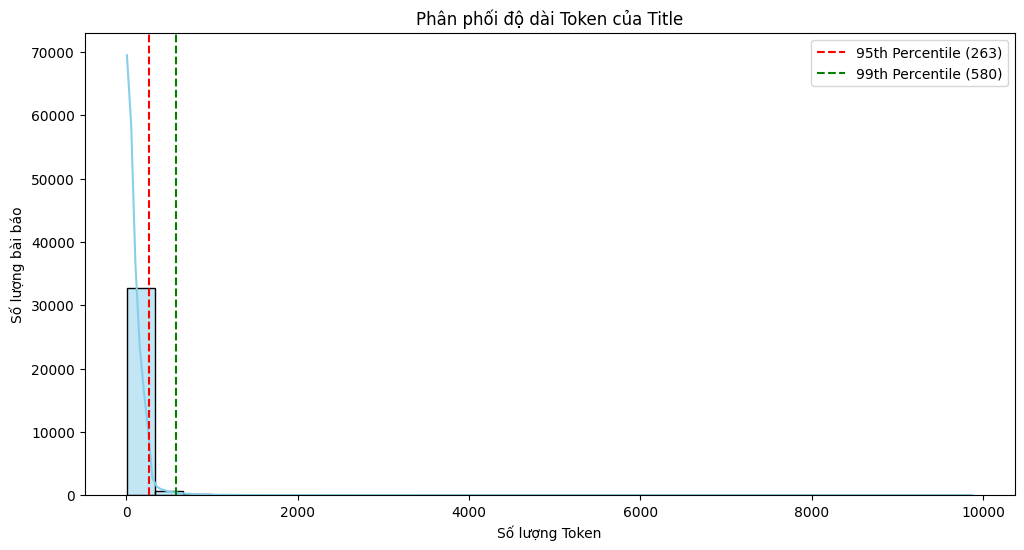


🚀 Gợi ý CONFIG['max_seq_length'] cho Title: 512


In [ ]:
# 4. Vẽ biểu đồ phân phối
plt.figure(figsize=(12, 6))

# Biểu đồ Histogram
sns.histplot(token_lens, bins=30, kde=True, color='skyblue')
plt.axvline(p95, color='red', linestyle='--', label=f'95th Percentile ({int(p95)})')
plt.axvline(p99, color='green', linestyle='--', label=f'99th Percentile ({int(p99)})')

plt.title('Phân phối độ dài Token của Title')
plt.xlabel('Số lượng Token')
plt.ylabel('Số lượng bài báo')
plt.legend()
plt.show()

# 5. Hàm gợi ý
def suggest_max_length(p99):
    # Bo tròn lên các lũy thừa của 2 hoặc số tròn chục để tối ưu cho GPU
    for limit in [32, 64, 96, 128, 192, 256]:
        if p99 <= limit:
            return limit
    return 512

suggested = suggest_max_length(p99)
print(f"\n🚀 Gợi ý CONFIG['max_seq_length'] cho Title: {suggested}")